In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import sys
import math
import random
import logging

# Prevent Python from generating .pyc files (compiled bytecode files)
sys.dont_write_bytecode = True

# Import necessary modules and configuration settings
from prompts import *
from utils import *
from model import *
from config     import *

# HuggingFace BERT tokenizer and model for embedding generation
from transformers import BertTokenizer, BertModel
import torch.nn.functional as F

In [ ]:
gold = readPickle(outputFileTransformedFull)

[2026-02-04 11:54:29] Reading file 'generated_300_medgemma-27b-text-it.pkl'.
[2026-02-04 11:54:29] Reading file 'generated_300_medgemma-27b-text-it.pkl' completed.


In [ ]:
synonyms = gold[gold[classColumn].isin(synonymClasses)].copy().reset_index(drop=True)

In [ ]:
parents = {}
children = {}

with newProgress() as progress:

    task = newTask(progress, len(set(synonyms[hpoidColumn].tolist())), "Get Parents and Children")

    hpoIDs = list(set(synonyms[hpoidColumn].tolist()))
    for hpoID in hpoIDs:
        children[hpoID] = getChildLabels(synonyms, hpoID)
        parents[hpoID] = getParentLabels(synonyms, hpoID)
        progress.update(task, advance=1)
    
    progress.refresh()

Output()

In [ ]:
logging.getLogger("vllm").setLevel(logging.ERROR)
log(f"Set up the LLM ({model_id})...")
model = Model(model=model_id)

In [ ]:
messages = []

for index, row in synonyms.iterrows():
    hpoID = row[hpoidColumn]

    messages.append(getSynonymClassPrompt(
        "".join(getElements(synonyms, hpoID, labelClass)),
        "".join(getElements(synonyms, hpoID, definitionClass)),
        "".join(getElements(synonyms, hpoID, commentClass)),
        parents[hpoID],
        children[hpoID],
        row[contentColumn]
    ))

addedPrompts = model.addPrompt(userRole, messages)
log(f"{addedPrompts} prompts added. Start generating responses...")
model.generate()

INFO 01-30 08:50:50 [utils.py:253] non-default args: {'max_model_len': 2048, 'tensor_parallel_size': 4, 'disable_log_stats': True, 'model': 'google/medgemma-27b-text-it'}


INFO 01-30 08:50:51 [model.py:514] Resolved architecture: Gemma3ForCausalLM
INFO 01-30 08:50:51 [model.py:1661] Using max model len 2048
INFO 01-30 08:50:51 [scheduler.py:230] Chunked prefill is enabled with max_num_batched_tokens=8192.
(EngineCore_DP0 pid=2963213) INFO 01-30 08:50:54 [core.py:93] Initializing a V1 LLM engine (v0.13.0) with config: model='google/medgemma-27b-text-it', speculative_config=None, tokenizer='google/medgemma-27b-text-it', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=4, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_par

Loading safetensors checkpoint shards:   0% Completed | 0/11 [00:00<?, ?it/s]


(EngineCore_DP0 pid=2963213) (Worker_TP0 pid=2963227) INFO 01-30 08:51:10 [default_loader.py:308] Loading weights took 7.18 seconds
(EngineCore_DP0 pid=2963213) (Worker_TP0 pid=2963227) INFO 01-30 08:51:11 [gpu_model_runner.py:3659] Model loading took 12.9584 GiB memory and 8.426086 seconds
(EngineCore_DP0 pid=2963213) (Worker_TP0 pid=2963227) INFO 01-30 08:51:25 [backends.py:643] Using cache directory: /home/pallaoro/.cache/vllm/torch_compile_cache/8ccf3f08bc/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=2963213) (Worker_TP0 pid=2963227) INFO 01-30 08:51:25 [backends.py:703] Dynamo bytecode transform time: 13.29 s
(EngineCore_DP0 pid=2963213) (EngineCore_DP0 pid=2963213) (EngineCore_DP0 pid=2963213) (EngineCore_DP0 pid=2963213) (Worker_TP3 pid=2963233) (Worker_TP0 pid=2963227) (Worker_TP2 pid=2963231) (Worker_TP1 pid=2963229) INFO 01-30 08:51:39 [backends.py:226] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 4.938 s
INFO 01-30 08

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:11<00:00,  4.53it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:05<00:00,  6.09it/s]


(EngineCore_DP0 pid=2963213) (Worker_TP0 pid=2963227) INFO 01-30 08:51:59 [gpu_model_runner.py:4587] Graph capturing finished in 18 secs, took 2.26 GiB
(EngineCore_DP0 pid=2963213) INFO 01-30 08:51:59 [core.py:259] init engine (profile, create kv cache, warmup model) took 47.68 seconds
INFO 01-30 08:52:00 [llm.py:360] Supported tasks: ['generate']
[2026-01-30 08:52:00] Max Num batched Tokens: 4096
[2026-01-30 08:52:00] Max new Tokens: 1024
[2026-01-30 08:52:00] Temperature: 0.01
[2026-01-30 08:52:00] Max Model Length: 2048
[2026-01-30 08:52:19] 3629 prompts added. Start generating responses...


Adding requests:   0%|          | 0/3629 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/3629 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

In [ ]:
histories = model.getMessageHistories().copy()
model.__del__()

In [ ]:
def formatAnswer(txt : str) -> str:
    ret = undefinedSynonymType

    if txt is not None:
        ret = txt.lower()
        if unusedTokens in ret:
            ret = ret[ret.index(unusedTokens) + len(unusedTokens):]

        if exactSynonymClass in ret and broadSynonymClass not in ret and narrowSynonymClass not in ret and relatedSynonymClass not in ret:
            ret = exactSynonymClass
        else:
            if exactSynonymClass not in ret and broadSynonymClass in ret and narrowSynonymClass not in ret and relatedSynonymClass not in ret:
                ret = broadSynonymClass
            else:
                if exactSynonymClass not in ret and broadSynonymClass not in ret and narrowSynonymClass in ret and relatedSynonymClass not in ret:
                    ret = narrowSynonymClass
                else:
                    if exactSynonymClass not in ret and broadSynonymClass not in ret and narrowSynonymClass not in ret and relatedSynonymClass in ret:
                        ret = relatedSynonymClass
                    else:
                        ret = undefinedSynonymType

    return ret

In [ ]:
synonyms[answerColumn] = [""] * len(synonyms.index)
for index, history in enumerate(histories):
    answer = str(history[-1][messageTextElement]).replace("\n", "").strip()
    synonyms.loc[index, answerColumn] = formatAnswer(answer)

In [ ]:
classes = synonyms[classColumn].tolist()
for c in synonymClasses:
    print(f"{c}: {classes.count(c)}")

exact: 3337
related: 162
broad: 83
narrow: 47


In [ ]:
# Load pretrained BERT model and tokenizer
log("Load BERT Tokenizer...")
tokenizer = BertTokenizer.from_pretrained("abhinand/MedEmbed-large-v0.1")
model = BertModel.from_pretrained("abhinand/MedEmbed-large-v0.1")
log("BERT Tokenizer loaded.")

In [ ]:
# Generate a BERT embedding for a single text input
def get_bert_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    with torch.no_grad():
        outputs = model(**inputs)
    # Use [CLS] token embedding as sentence representation
    return outputs.last_hidden_state[:, 0, :].squeeze()

# Generate embeddings for a list of strings with progress reporting
def embed(data: list) -> list:
    ret = [[] for _ in range(0, len(data))]

    with newProgress() as progress:
        task = newTask(progress, len(data), "Generate Embeddings")

        for index, l in enumerate(data):
            if l is not None and len(l) > 0:
                ret[index] = get_bert_embedding(l)
            else:
                ret[index] = None
            progress.update(task, advance=1)

    # Stack embeddings into a single tensor
    return torch.stack(ret)

def cosine_similarity(emb1: torch.Tensor, emb2: torch.Tensor) -> float:
    return F.cosine_similarity(emb1, emb2, dim=0).item()

[2026-01-30 08:57:12] Load BERT Tokenizer...
[2026-01-30 08:57:13] BERT Tokenizer loaded.


In [ ]:
log("Computing Similarity...")
# Process each LLM answer and extract synonyms
with newProgress() as progress:
    task = newTask(progress, len(synonyms.index), "Calculating Similarity...")

    for index, synonym in synonyms.iterrows():
        if synonym[answerColumn] != "" and synonym[classColumn] in synonymClasses:
            label_embedding = get_bert_embedding(
                "".join(getElements(synonyms, synonym[hpoidColumn], labelClass))
            )
            synonym_embedding = get_bert_embedding(synonym[contentColumn])
            
            synonyms.loc[index, "similarity"] = cosine_similarity(label_embedding, synonym_embedding)
        
        progress.update(task, advance=1)

    progress.refresh()
    
log("Similarity Computed.")

Output()

In [ ]:
threshold = []
accuracy = []
recall = []
f1 = []
precision = []
FN_A = []
for i in np.arange(0.2, 0.99, 0.01):
    TP = sum((synonyms[classColumn] == exactSynonymClass) & ((synonyms["similarity"] >= i) | (exactSynonymClass == synonyms[answerColumn])))
    TN = sum((synonyms[classColumn] != exactSynonymClass) & ((synonyms["similarity"] < i)  & (exactSynonymClass != synonyms[answerColumn])))
    FN = sum((synonyms[classColumn] == exactSynonymClass) & ((synonyms["similarity"] < i)  & (exactSynonymClass != synonyms[answerColumn])))
    FP = sum((synonyms[classColumn] != exactSynonymClass) & ((synonyms["similarity"] >= i) | (exactSynonymClass == synonyms[answerColumn])))

    accuracy.append((TP + TN) / (TP + TN + FP + FN))
    recall.append((TP / (TP + FN)))
    precision.append((TP / (TP + FP)))
    f1.append(2 * precision[-1] * recall[-1] / (precision[-1] + recall[-1]))
    threshold.append(i)
    FN_A.append(FN)

print()
print(accuracy)
print(recall)
print(precision)
print(f1)
print(threshold)
print(FN_A)

3629

[0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.9195370625516671, 0.918710388536787, 0.918710388536787, 0.918710388536787, 0.918710388536787, 0.918710388536787, 0.918985946541747, 0.918434830531827, 0.9181592725268669, 0.9181592725268669, 0.918434830531827, 0.9181592725268669, 0.9181592725268669, 0.9173325985119868, 0.9170570405070267, 0.9167814825020667, 0.9162303664921466, 0.9145770184623864, 0.9131992284375862, 0.9118214384127858, 0

In [17]:
print(f"Correct:     {sum((sample[classColumn] == exactSynonymClass) & (sample[answerColumn] == exactSynonymClass))}")
print(f"Correct:     {sum((sample[classColumn] != exactSynonymClass) & (sample[answerColumn] != exactSynonymClass))}")
print(f"Not Correct: {sum((sample[classColumn] == exactSynonymClass) & (sample[answerColumn] != exactSynonymClass))}")
print(f"Not Correct: {sum((sample[classColumn] != exactSynonymClass) & (sample[answerColumn] == exactSynonymClass))}")
print(f"Undefined: {sum(sample[answerColumn] == 'undefined')}")

Correct:     3108
Correct:     45
Not Correct: 229
Not Correct: 247
Undefined: 7


In [19]:
for index, s in sample.iterrows():
    if s[answerColumn] != s[classColumn] and (s[classColumn] == exactSynonymClass or s[answerColumn] == exactSynonymClass):
        l = quote(''.join(getElements(gold, s[hpoidColumn], labelClass)))
        print(f"LLM Answer: \"{s[answerColumn]}\" != Correct: \"{s[classColumn]}\" [Label: {l}, Synonym: {quote(s[contentColumn])}]")

LLM Answer: "narrow" != Correct: "exact" [Label: "Abnormal heart morphology", Synonym: "Congenital heart defect"]
LLM Answer: "narrow" != Correct: "exact" [Label: "Abnormal heart morphology", Synonym: "Congenital heart defects"]
LLM Answer: "narrow" != Correct: "exact" [Label: "Agenesis of corpus callosum", Synonym: "Dysplastic or absent corpus callosum"]
LLM Answer: "exact" != Correct: "related" [Label: "Prominent nasal tip", Synonym: "Hypertrophy of tip of nose"]
LLM Answer: "exact" != Correct: "related" [Label: "Prominent nasal tip", Synonym: "Hypertrophy of nasal tip"]
LLM Answer: "exact" != Correct: "related" [Label: "Prominent nasal tip", Synonym: "Hyperplasia of tip of nose"]
LLM Answer: "exact" != Correct: "related" [Label: "Prominent nasal tip", Synonym: "Hyperplasia of nasal tip"]
LLM Answer: "exact" != Correct: "narrow" [Label: "Prominent nasal tip", Synonym: "Bulbous tip of nose"]
LLM Answer: "exact" != Correct: "related" [Label: "Concave nasal ridge", Synonym: "Saddle nose

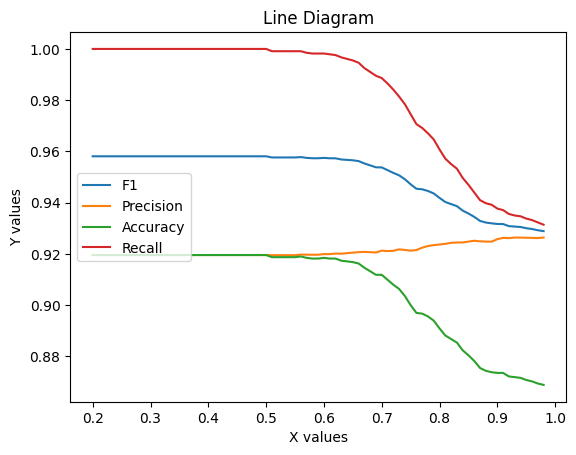

In [20]:
# Create line plot
plt.plot(threshold, f1, label="F1")
plt.plot(threshold, precision, label="Precision")
plt.plot(threshold, accuracy, label="Accuracy")
plt.plot(threshold, recall, label="Recall")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Line Diagram")
plt.legend(loc="center left")

# Show plot
plt.show()

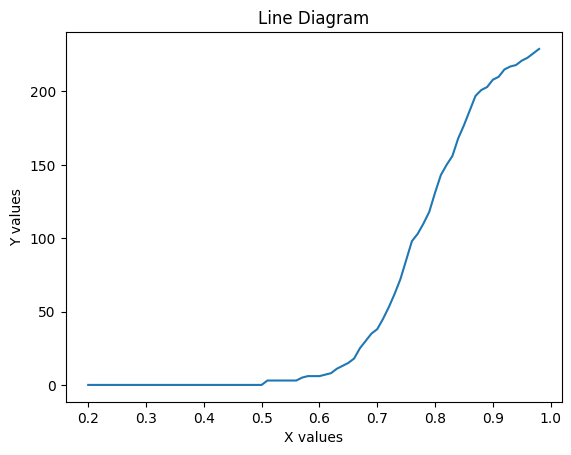

In [21]:
# Create line plot
plt.plot(threshold, FN_A)
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Line Diagram")

# Show plot
plt.show()

In [22]:
for idx, s in sample.iterrows():
    if s["similarity"] == 0.0:
        print(f"{''.join(getElements(gold, s[hpoidColumn], labelClass))} != {s[contentColumn]}")

In [23]:
str(histories[0][0]["message"])

'Your Task:\n\nYou are given a primary Human Phenotype Ontology (HPO) concept and a candidate synonym. Using only the information provided and HPO curation conventions, classify the synonym into exactly one of the following classes:\n\n"Exact", "Broad", "Narrow", or "Related"\n\nYour goal is to decide whether the candidate synonym could be used interchangeably with the primary label in phenotype annotation, not whether it is clinically, mechanistically, or etiologically identical.\n\nMandatory ontology rules:\n\nApply all of the following rules:\n- Collapse etiology, timing, and mechanism: Ignore differences such as congenital vs acquired, mechanism vs manifestation, histology vs appearance, or cause vs effect unless the synonym explicitly excludes part of the label’s meaning.\n- Treat historical, pathological, and descriptive disease names as "Exact": If multiple names refer to the same recognized disease entity (including deprecated, histologic, or descriptive names), classify as "Ex

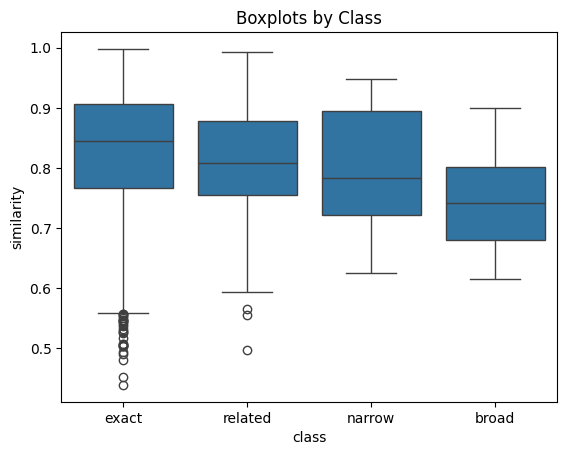

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=classColumn, y="similarity", data=sample[sample[classColumn].isin(synonymClasses)].copy().reset_index(drop=True))
plt.title("Boxplots by Class")
plt.show()

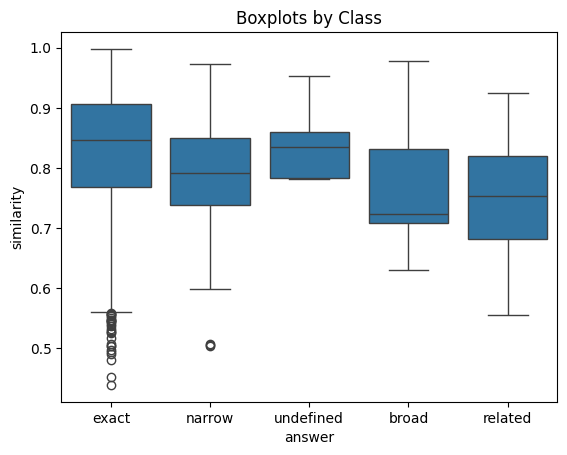

In [25]:
sns.boxplot(x=answerColumn, y="similarity", data=sample[sample[classColumn].isin(synonymClasses)].copy().reset_index(drop=True))
plt.title("Boxplots by Class")
plt.show()

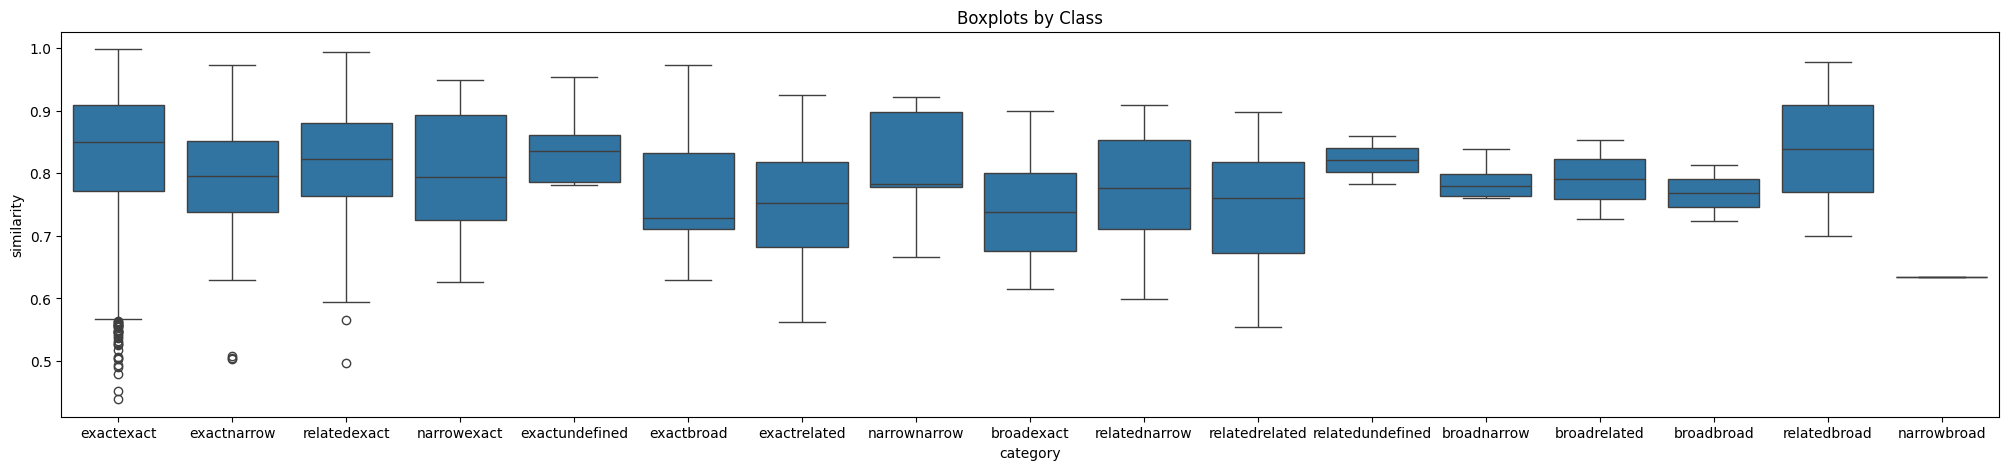

In [26]:
sample["category"] = [str(s[classColumn]) + str(s[answerColumn]) for index, s in sample.iterrows()]
plt.figure(figsize=(25, 5))
sns.boxplot(x="category", y="similarity", data=sample[sample[classColumn].isin(synonymClasses)].copy().reset_index(drop=True))
plt.title("Boxplots by Class")
plt.show()

[2026-02-04 13:22:35] ========================================================================================================================
[2026-02-04 13:22:35] =                                                Evaluating the Results                                                =
[2026-02-04 13:22:35] ========================================================================================================================
[2026-02-04 13:22:35] Reading file 'Reading "generation_merged_terms_300.csv"...'.
[2026-02-04 13:22:37] Reading file 'Read "generation_merged_terms_300.csv".'.
[2026-02-04 13:22:37] Reading file 'Reading "generation_gold.csv"...'.
[2026-02-04 13:22:37] Reading file 'Read "generation_gold.csv"...'.
[2026-02-04 13:22:37] Found Systems: "medgemma-27b-text-it"
[2026-02-04 13:22:37] Creating Plot 'Overall Amount of Distinct Generated Synonyms per Round'...
[2026-02-04 13:23:08] Creaed Plot 'Overall Amount of Distinct Generated Synonyms per Round'.
[2026-02-04 13:23:08]

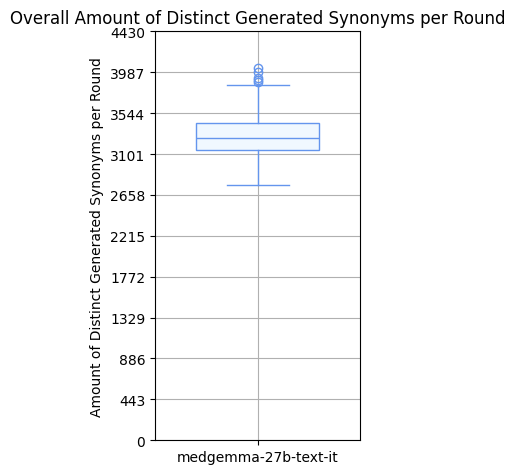

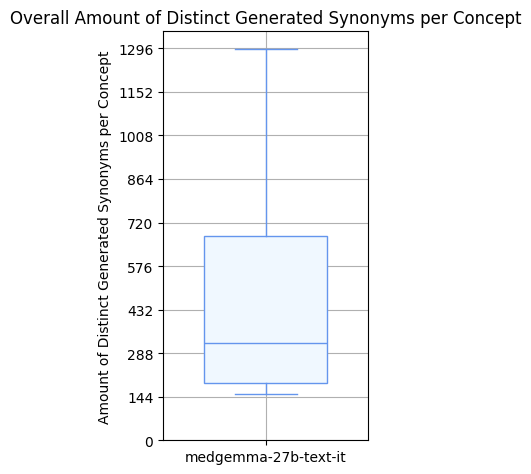

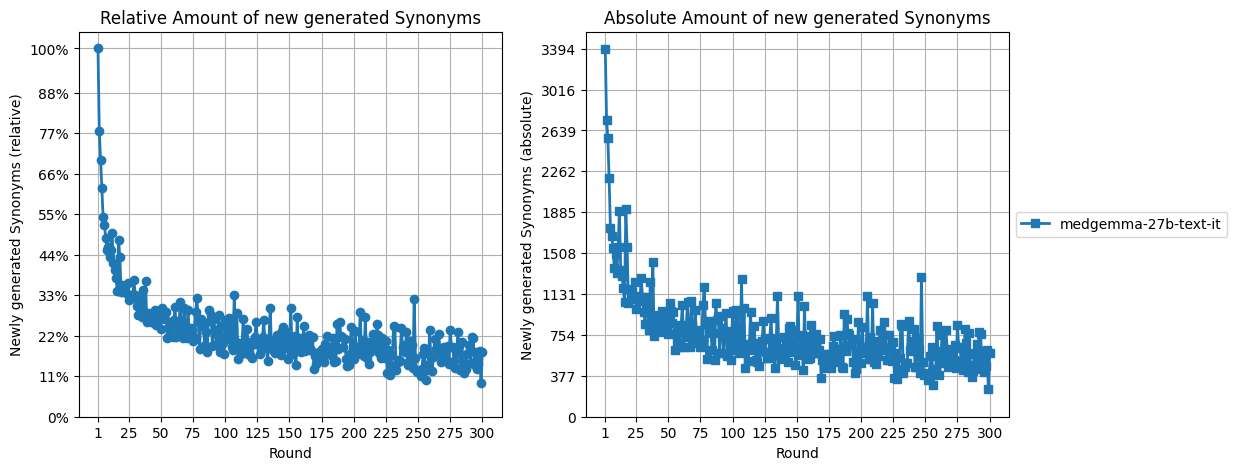

In [9]:
import pandas               as pd
import numpy                as np
import matplotlib.pyplot    as plt
import sys
import math

# Prevent Python from generating .pyc files (compiled bytecode files)
sys.dont_write_bytecode = True

# Import necessary modules and configuration settings
from prompts    import *
from model      import *
from utils      import *
from config     import *

printHeader("Evaluating the Results")

printRead(f"Reading \"{os.path.basename(inputFileGenerationEvaluation)}\"...")
generated = pd.read_csv(inputFileGenerationEvaluation).reset_index(drop=True).copy()
generated[contentColumn] = generated[hpoidColumn] + " " + generated[contentColumn]
printRead(f"Read \"{os.path.basename(inputFileGenerationEvaluation)}\".")

printRead(f"Reading \"{os.path.basename(inputFileGenerationEvaluationGold)}\"...")
gold = pd.read_csv(inputFileGenerationEvaluationGold).reset_index(drop=True)
printRead(f"Read \"{os.path.basename(inputFileGenerationEvaluationGold)}\"...")

labels = list(set(gold[gold[classColumn] == labelClass][contentColumn]))

goldExactSynonymData    = gold[gold[classColumn] == exactSynonymClass]
goldData                = goldExactSynonymData[~goldExactSynonymData[contentColumn].isin(labels)].copy()
goldData[contentColumn] = goldData[hpoidColumn] + " " + goldData[contentColumn]

generated[systemColumn] = generated[systemColumn].fillna("")

systems = list(set(generated[systemColumn].tolist()))
systemsName = []
for system in systems:
    if len(system) > 0:
        systemsName.append(system[str(system).index("/") + 1:])


string = '", "'.join(systemsName)
log(f"Found Systems: \"{string}\"")
generated   = generated[generated[systemColumn] != ""]
systems     = list(set(generated[systemColumn].tolist()))

colors = plt.cm.tab10(range(len(systems) + 1))

roundCount = int(max(generated[roundColumn].tolist()))

xRoundTicks     = 25
xRound          = np.arange(1, roundCount + 1)
xRoundTickList  = [1] + list(np.arange(xRoundTicks, roundCount + 1, xRoundTicks))

def getSystemRoundData(data : pd.DataFrame, system : str, round : int) -> list:
    # Reduce Data to System data
    systemData = data[data[systemColumn] == system]
    # Reduce Data to Round data
    systemRoundData = systemData[systemData[roundColumn] == round]
    
    return list(set(systemRoundData[contentColumn].tolist()))

def getCumulativeSystemRoundData(data : pd.DataFrame, system : str, round : int) -> list:
    # Reduce Data to System data
    systemData = data[data[systemColumn] == system]
    # Reduce Data to Round and pre-Round data
    systemRoundData = systemData[systemData[roundColumn] <= round]
    
    return list(set(systemRoundData[contentColumn].tolist()))

def getCumulativeSystemRoundHPOData(data : pd.DataFrame, system : str, round : int, hpoID : str) -> list:
    # Reduce Data to System data
    systemData = data[data[systemColumn] == system]
    # Reduce Data to Round data
    systemRoundData = systemData[systemData[roundColumn] <= round]
    # Reduce Data to HPO ID data
    systemRoundHPOData = systemRoundData[systemRoundData[hpoidColumn] == hpoID]
    
    return list(set(systemRoundHPOData[contentColumn].tolist()))

def getNewSynonymsSystemRound(data : pd.DataFrame, system : str, round : int) -> list:
    ret = []

    systemData = data[data[systemColumn] == system]
    # Reduce Data to Round data

    if round == 0:
        ret = list(set(systemData[systemData[roundColumn] == 0][contentColumn]))
    else:
        systemRoundData = systemData[systemData[roundColumn] <= round][contentColumn].tolist()
        systemPreviousRoundData = systemData[systemData[roundColumn] <= round - 1][contentColumn].tolist()

        ret = list(set(systemRoundData).difference(set(systemPreviousRoundData)))

    return ret

def splitEqualParts(start : float, end : float, parts : int, cut : int = 2) -> list:
    ret = list(np.linspace(start, end, parts))
    for index in range(0, len(ret)):
        ret[index] = math.trunc(ret[index] * math.pow(10, cut)) / math.pow(10, cut)
    return ret

def splitEqualPartsLabels(start : float, end : float, parts : int, cut : int = 2, prefix : str = "", postfix : str = "", multiplier : int = 1) -> list:
    ret = splitEqualParts(start, end, parts, cut)

    for index in range(0, len(ret)):

        value = str(ret[index] * multiplier)

        if "." in value:
            value = value.split(".")
            
            if cut > 0:
                if len(value[1]) > cut:
                    tmp = value[1]
                    value[1] = str(round(float(tmp[0:cut])))
            else:
                value[1] = "0"

            if not value[1] == "0":
                value = ".".join(value)
            else:
                value = value[0]

        ret[index] = prefix + str(value) + postfix

    return ret

log("Creating Plot 'Overall Amount of Distinct Generated Synonyms per Round'...")

result = {}
maxVal = 0

for system in systems:
    count = [0] * roundCount

    for r in range(0, roundCount):
        count[r] = len(getSystemRoundData(generated, system, r + 1))
        if count[r] > maxVal:
            maxVal = count[r]

    result[system] = {"counts" : count}

yticks = 10

# Extract data for plotting
data = [result[system]["counts"] for system in systems]

# Create the boxplot
plt.figure(figsize=(3 * len(systems), 5))
plt.boxplot(
    data,
    showfliers=True,
    widths=[0.6] * len(systems),
    patch_artist=True,
    boxprops=dict(facecolor="aliceblue", color="cornflowerblue"),
    medianprops=dict(color="cornflowerblue"),
    whiskerprops=dict(color="cornflowerblue"),
    capprops=dict(color="cornflowerblue"),
    flierprops=dict(markeredgecolor="cornflowerblue")
)
plt.title("Overall Amount of Distinct Generated Synonyms per Round")
plt.suptitle("")
plt.xlabel("")
plt.xticks(range(1, len(systems) + 1), labels=systemsName)
plt.ylabel("Amount of Distinct Generated Synonyms per Round")
plt.yticks(range(0, int(maxVal * 1.1) , int(maxVal * 1.1 / yticks)))
plt.tight_layout()
plt.grid(visible=True)
plt.savefig(outputFileGenerationDistinctSynonymsRound, dpi=300, bbox_inches="tight")
log("Creaed Plot 'Overall Amount of Distinct Generated Synonyms per Round'.")

log("Creating Plot 'Overall Amount of Distinct Generated Synonyms per Concept'...")
result = {}
maxVal = 0

for system in systems:
    count = [0] * len(testIDs)

    for index, hpoID in enumerate(testIDs):
        count[index] = len(getCumulativeSystemRoundHPOData(generated, system, roundCount + 1, hpoID))
        if count[index] > maxVal:
            maxVal = count[index]

    result[system] = {
        "counts" : count 
    }

yticks = math.ceil(maxVal / 500)

# Extract data for plotting
data = [result[system]["counts"] for system in systems]

# Create the boxplot
plt.figure(figsize=(3 * len(systems), 5))
plt.boxplot(
    data,
    showfliers      = True,
    widths          = [0.6] * len(systems),
    patch_artist    = True,
    boxprops        = dict(facecolor="aliceblue", color="cornflowerblue"),
    medianprops     = dict(color="cornflowerblue"),
    whiskerprops    = dict(color="cornflowerblue"),
    capprops        = dict(color="cornflowerblue"),
    flierprops      = dict(markeredgecolor="cornflowerblue")
)
plt.title("Overall Amount of Distinct Generated Synonyms per Concept")
plt.suptitle("")
plt.xlabel("")
plt.xticks(range(1, len(systems) + 1), labels=systemsName)
plt.ylabel("Amount of Distinct Generated Synonyms per Concept")

yticksList      = splitEqualParts       (0, maxVal + 1, 10, 0)
yticksLabels    = splitEqualPartsLabels (0, maxVal + 1, 10, 0)
plt.yticks(ticks = yticksList, labels = yticksLabels
)

plt.tight_layout()
plt.grid(visible=True)
plt.savefig(outputFileGenerationDistinctSynonymsConcept, dpi=300, bbox_inches="tight")
log("Created Plot 'Overall Amount of Distinct Generated Synonyms per Concept'.")

log("Creating Plot 'Relative Amount of new generated Synonyms'...")
result = {}
maxVal = 0

for index, system in enumerate(systems):
    counts      = [0] * roundCount
    relatives   = [0] * roundCount
    
    for r in range(0, roundCount):
        counts[r]       = len(getNewSynonymsSystemRound(generated, system, r + 1))
        relatives[r]    = counts[r] / len(getSystemRoundData(generated, system, r + 1))

        if counts[r] > maxVal:
            maxVal = counts[r]

    result[system] = {
        "counts" : counts,
        "relatives" : relatives
    }

_, axs = plt.subplots(1, 2, figsize=(12, 5))

yticks = math.ceil(maxVal / 5)

for system in result.keys():
    axs[0].plot(xRound, result[system]["relatives"] , marker='o', color=colors[systems.index(system)], linewidth=2, label=systemsName[systems.index(system)])
    axs[1].plot(xRound, result[system]["counts"]    , marker='s', color=colors[systems.index(system)], linewidth=2, label=systemsName[systems.index(system)])

axs[0].set_xlabel("Round")
axs[0].set_ylabel("Newly generated Synonyms (relative)")
axs[0].grid(True)
axs[0].set_yticks(splitEqualParts(0, 1, 10, 2))
axs[0].set_yticklabels(splitEqualPartsLabels(0, 1, 10, 2, "", "%", 100))
axs[0].set_xticks(xRoundTickList)
axs[0].set_title("Relative Amount of new generated Synonyms")

axs[1].set_yticks(splitEqualParts(0, maxVal + 1, 10, 0)) 
axs[1].set_yticklabels(splitEqualPartsLabels(0, maxVal + 1, 10, 0))
axs[1].set_ylabel("Newly generated Synonyms (absolute)")
axs[1].set_xticks(xRoundTickList)
axs[1].set_xlabel("Round")
axs[1].grid(True)
axs[1].set_title("Absolute Amount of new generated Synonyms")

# Combine legends from both axes
lines_1, labels_1 = axs[0].get_legend_handles_labels()
lines_2, labels_2 = axs[1].get_legend_handles_labels()
axs[1].legend(lines_1 + lines_2, labels_1 + labels_2)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.savefig(outputFileGenerationNewSynonymsRound, dpi=300, bbox_inches="tight")
log("Created Plot 'Relative Amount of new generated Synonyms'.")

In [1]:
import pandas as pd
import sys
import os
import time

# Prevent Python from generating .pyc files (compiled bytecode files)
sys.dont_write_bytecode = True

# Import project-specific helpers, model wrappers, and configuration
from prompts    import *
from utils      import *

# Print a formatted header indicating the start of this processing stage
printHeader(f"Merging Generated Classifications")
start_time = time.time()

# Merging Generated Classes
if len(inputFileClassificationMerged) == 0:
    log(f"No '{csvFileFormat}' files with prefix " + 
        f"'{outputFileNameClassificationFormattedPrefix}' found in " + 
        f"'{outputFolderNameFormatted}'")
else:
    # Read and merge CSV files
    dataframes = []
    log("Reading files...")
    with newProgress() as progress:
        task = newTask(progress, len(inputFileClassificationMerged), 
            "Processing Files")

        for file in sorted(inputFileClassificationMerged):
            dataframes.append(pd.read_csv(file, index_col=None))
            progress.update(task, advance = 1)

        progress.refresh()

    # Read and merge CSV files
    log("Files read.")

    log("Merging Data...")
    merged_df = pd.concat(dataframes, ignore_index = True)
    merged_df = merged_df.reset_index(drop = True)
    log("Data merged.")

    # Write merged CSV
    writeCSV(merged_df, outputFileClassificationMerged)

    log(f"Merged {len(inputFileClassificationMerged)} files into " + 
        f"'{os.path.basename(outputFileClassificationMerged)}'")

end_time = time.time()
elapsed_seconds = end_time - start_time
minutes = int(elapsed_seconds // 60)

# Print a formatted header indicating the end of this processing stage
printHeader(f"Data Merged [Minutes: {minutes}]")

Output()

[2026-02-09 14:10:03] ========================================================================================================================
[2026-02-09 14:10:03] =                                          Merging Generated Classifications                                           =
[2026-02-09 14:10:03] ========================================================================================================================
[2026-02-09 14:10:03] Reading files...


[2026-02-09 14:10:03] Files read.
[2026-02-09 14:10:03] Merging Data...
[2026-02-09 14:10:03] Data merged.
[2026-02-09 14:10:03] Writing file 'classification_merged_classes.csv'.
[2026-02-09 14:10:04] Writing file 'classification_merged_classes.csv' completed.
[2026-02-09 14:10:04] Merged 2 files into 'classification_merged_classes.csv'
[2026-02-09 14:10:04] ========================================================================================================================
[2026-02-09 14:10:04] =                                               Data Merged [Minutes: 0]                                               =
[2026-02-09 14:10:04] ========================================================================================================================
